# 01-Infrastructure as Code (IaC) & Python SDKs

In the previous sections, we built massive distributed data pipelines. In an Enterprise environment, these pipelines require physical hardware (servers, networking, databases).

Historically, engineers logged into a Cloud Web Console and manually clicked buttons to provision infrastructure. This is known as **ClickOps**. ClickOps is physically unscalable, mathematically irreproducible, and impossible to version-control. To achieve Enterprise Cloud Engineering, we must define our entire global data center topology using **Infrastructure as Code (IaC)**.

Because learning cloud engineering should not incur financial risk, we are building this entire architecture locally. We will write real AWS Boto3 code and real HashiCorp Terraform code, but we will mathematically vector those commands into a local Docker container running **LocalStack**.

Let's configure our environment to escape the Web Console and engineer physical hardware programmatically for exactly $0.00.

In [5]:
# Required installations: pip install boto3 matplotlib seaborn
# Prerequisite: Docker must be running on your machine with `localstack/localstack` deployed
import boto3
import json
import time
from botocore.exceptions import ClientError
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & LocalStack IaC Engine Initialized.")

✅ Systems Architecture & LocalStack IaC Engine Initialized.


### 1. Install Docker

Download and install **Docker Desktop** for your operating system:

- **Windows:** https://www.docker.com/products/docker-desktop/
- **macOS:** https://www.docker.com/products/docker-desktop/
- **Linux:** https://docs.docker.com/engine/install/

After installation, verify Docker is running:

```bash
docker --version
```

Example output:

```text
Docker version 28.x.x
```

Also verify the Docker daemon:

```bash
docker ps
```

You should see an empty container list if Docker is running correctly.

---

### 2. Pull the LocalStack Image

Download the latest LocalStack container:

```bash
docker pull localstack/localstack:3.8
```

---

### 3. Start LocalStack

Launch LocalStack in detached mode:

```bash
docker run -d \
  --name localstack \
  -p 4566:4566 \
  -e SERVICES=s3,dynamodb \
  localstack/localstack:3.8
```

If you're using PowerShell:

```powershell
docker run -d `
  --name localstack `
  -p 4566:4566 `
  localstack/localstack
```

---

### 4. Verify the Container

List running containers:

```bash
docker ps
```

Expected output:

```text
CONTAINER ID   IMAGE                     STATUS
xxxxxxxxxxxx   localstack/localstack     Up ...
```

---

### 5. Verify LocalStack

Open:

```
http://localhost:4566
```

or test via terminal:

```bash
curl http://localhost:4566
```

A response confirms LocalStack is listening for AWS API requests.

---

# 1. The Mathematics of Cloud State ($\mathbf{S}$)

In Cloud Engineering, the physical hardware running your applications is represented as a mathematical State Vector $\mathbf{S}$.
At any given time $t$, your cloud environment consists of a set of instantiated resources (VPCs, EC2 instances, S3 buckets):


$$\mathbf{S}_{t} = \{r_1, r_2, \dots, r_n\}$$

There are two primary paradigms for mutating this state: **Imperative** and **Declarative**.

### 1. Imperative Provisioning (Python / Boto3)

Imperative programming commands the cloud *how* to change the state. You write sequential API calls: "Create Bucket X", "Wait 5 seconds", "Create Database Y".


$$f_{imperative}(\mathbf{S}_{t}) \rightarrow \mathbf{S}_{t+1}$$


**The Danger:** If your script crashes halfway through, you are left with a fractured state. If you run the script again, the cloud will throw a `ResourceAlreadyExistsException`, and the pipeline dies.

### 2. Declarative Provisioning (Terraform)

Declarative programming commands the cloud *what* the final state should look like, ignoring the "how". You define the Desired State ($\mathbf{S}_{desired}$) in a static file.

The IaC engine (Terraform) reads the Current Physical State ($\mathbf{S}_{current}$), calculates the mathematical topological Delta ($\Delta \mathbf{S}$), and autonomously executes the exact API calls required to reconcile reality with the blueprint:


$$\Delta \mathbf{S} = \mathbf{S}_{desired} - \mathbf{S}_{current}$$


If $\Delta \mathbf{S} = \emptyset$, Terraform does absolutely nothing. This guarantees strict **Idempotency** ($\mathcal{O}(1)$ safety upon multiple executions).

# 2. Imperative Execution: The AWS Boto3 SDK (Local Interception)

Let's build cloud infrastructure using Python. We will write an imperative script using `boto3` to provision an Enterprise Data Lake landing zone (S3 Bucket) and a strict metadata locking table (DynamoDB).

To enforce the $0.00 cost, we inject an explicit `endpoint_url` parameter. This forces the Python SDK to send its AWS API payloads to our local port (4566) instead of the actual AWS `us-east-1` data center.

In [6]:
# --- ⚙️ STEP 1: Initializing the AWS Imperative Engine (LocalStack Vector) ---
print("--- 🚀 Initializing Boto3 Imperative Provisioning (Local Network) ---")

# We hardcode dummy credentials because LocalStack ignores them, but Boto3 requires them to compile
boto3.setup_default_session(aws_access_key_id='test', aws_secret_access_key='test', region_name='us-east-1')

# CRITICAL: We vector the API calls to our local Docker container
local_endpoint = 'http://localhost:4566'

s3_client = boto3.client('s3', endpoint_url=local_endpoint)
dynamodb_client = boto3.client('dynamodb', endpoint_url=local_endpoint)

bucket_name = "local-enterprise-dl-landing-zone"
table_name = "local-terraform-state-locks"

# --- 🪣 STEP 2: Provisioning Storage (S3) ---
try:
    print(f"   [API CALL] Attempting to create S3 Bucket: {bucket_name}")
    s3_client.create_bucket(Bucket=bucket_name)
    print("   ✅ Mock S3 Bucket successfully provisioned in LocalStack.")
    
except ClientError as e:
    # Imperative systems MUST manually handle idempotency errors
    if e.response['Error']['Code'] == 'BucketAlreadyOwnedByYou':
        print(f"   ⚠️ [IDEMPOTENCY] Bucket '{bucket_name}' already exists locally. Skipping.")
    else:
        raise e

# --- 🗄️ STEP 3: Provisioning Compute/Database (DynamoDB) ---
try:
    print(f"\n   [API CALL] Attempting to create DynamoDB Table: {table_name}")
    dynamodb_client.create_table(
        TableName=table_name,
        KeySchema=[{'AttributeName': 'LockID', 'KeyType': 'HASH'}],
        AttributeDefinitions=[{'AttributeName': 'LockID', 'AttributeType': 'S'}],
        BillingMode='PAY_PER_REQUEST'
    )
    print("   ✅ Mock DynamoDB Table successfully allocated in LocalStack.")
    
except ClientError as e:
    if e.response['Error']['Code'] == 'ResourceInUseException':
         print(f"   ⚠️ [IDEMPOTENCY] Table '{table_name}' already exists locally. Skipping.")
    else:
        raise e

print("\n--- 💡 Engineering Insight ---")
print("Boto3 is incredibly powerful, but using it for core infrastructure provisioning is brittle. Look at the `try/except` blocks. We had to manually write state-checking logic. If we were provisioning a 500-node VPC, writing this manual validation logic in Python would take thousands of lines of unmaintainable code. We need a declarative engine.")

--- 🚀 Initializing Boto3 Imperative Provisioning (Local Network) ---
   [API CALL] Attempting to create S3 Bucket: local-enterprise-dl-landing-zone
   ✅ Mock S3 Bucket successfully provisioned in LocalStack.

   [API CALL] Attempting to create DynamoDB Table: local-terraform-state-locks
   ✅ Mock DynamoDB Table successfully allocated in LocalStack.

--- 💡 Engineering Insight ---
Boto3 is incredibly powerful, but using it for core infrastructure provisioning is brittle. Look at the `try/except` blocks. We had to manually write state-checking logic. If we were provisioning a 500-node VPC, writing this manual validation logic in Python would take thousands of lines of unmaintainable code. We need a declarative engine.


# 3. Declarative Execution: HashiCorp Terraform (Local Mocking)

To solve the brittleness of imperative Python, Cloud Engineers use **Terraform**. You define the infrastructure in HashiCorp Configuration Language (HCL).

Here is the declarative equivalent of the Boto3 Python script above. Notice the `endpoints` block—this is the professional method for pointing production Terraform blueprints at a LocalStack sandbox.

```hcl
# --- 📜 main.tf (The Declarative Infrastructure Blueprint) ---

# 1. Define the Cloud Provider Physics (Mocked for LocalStack)
provider "aws" {
  region                      = "us-east-1"
  access_key                  = "mock_access_key"
  secret_key                  = "mock_secret_key"
  
  # CRITICAL: Disable AWS authentication checks so Terraform doesn't crash 
  # when it realizes we aren't talking to the real AWS API.
  skip_credentials_validation = true
  skip_metadata_api_check     = true
  skip_requesting_account_id  = true
  s3_use_path_style           = true

  # Vector the Terraform compiler to the local Docker container
  endpoints {
    s3       = "http://localhost:4566"
    dynamodb = "http://localhost:4566"
  }
}

# 2. Declare the Desired State of the S3 Bucket
resource "aws_s3_bucket" "landing_zone" {
  bucket = "local-enterprise-dl-landing-zone"
}

# 3. Declare the Desired State of the DynamoDB Table
resource "aws_dynamodb_table" "state_locks" {
  name         = "local-terraform-state-locks"
  billing_mode = "PAY_PER_REQUEST"
  hash_key     = "LockID"

  attribute {
    name = "LockID"
    type = "S"
  }
}

```

### The Physics of `terraform apply`

If you save that file and run `terraform apply` in your terminal:

1. Terraform connects to `localhost:4566` to download the Current State ($\mathbf{S}_{current}$).
2. It compares it to `main.tf` ($\mathbf{S}_{desired}$).
3. It autonomously compiles and executes the underlying REST API calls locally.
4. It costs $0.00 and can be destroyed instantly by running `terraform destroy`.

# 4. Visualizing Zero-Cost IaC State Reconciliation

To scientifically understand how LocalStack safely isolates your code from billing systems while still utilizing production-grade deployment engines, let's graph the topological flow of Local State Reconciliation.

/tmp/ipykernel_6015/3923746911.py:8: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0, 0.5), 5.5, 7, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
/tmp/ipykernel_6015/3923746911.py:12: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.5, 4.5), 4.5, 1.8, fill=True, color='#2c3e50', edgecolor='black'))
/tmp/ipykernel_6015/3923746911.py:30: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((7, 0.5), 6.5, 7, fill=True, color='#2ecc71', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
/tmp/ipykernel_6015/3923746911.py:34: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((7.5, 3.5), 5.5, 1.2, fill=True, color='#e67e22', e

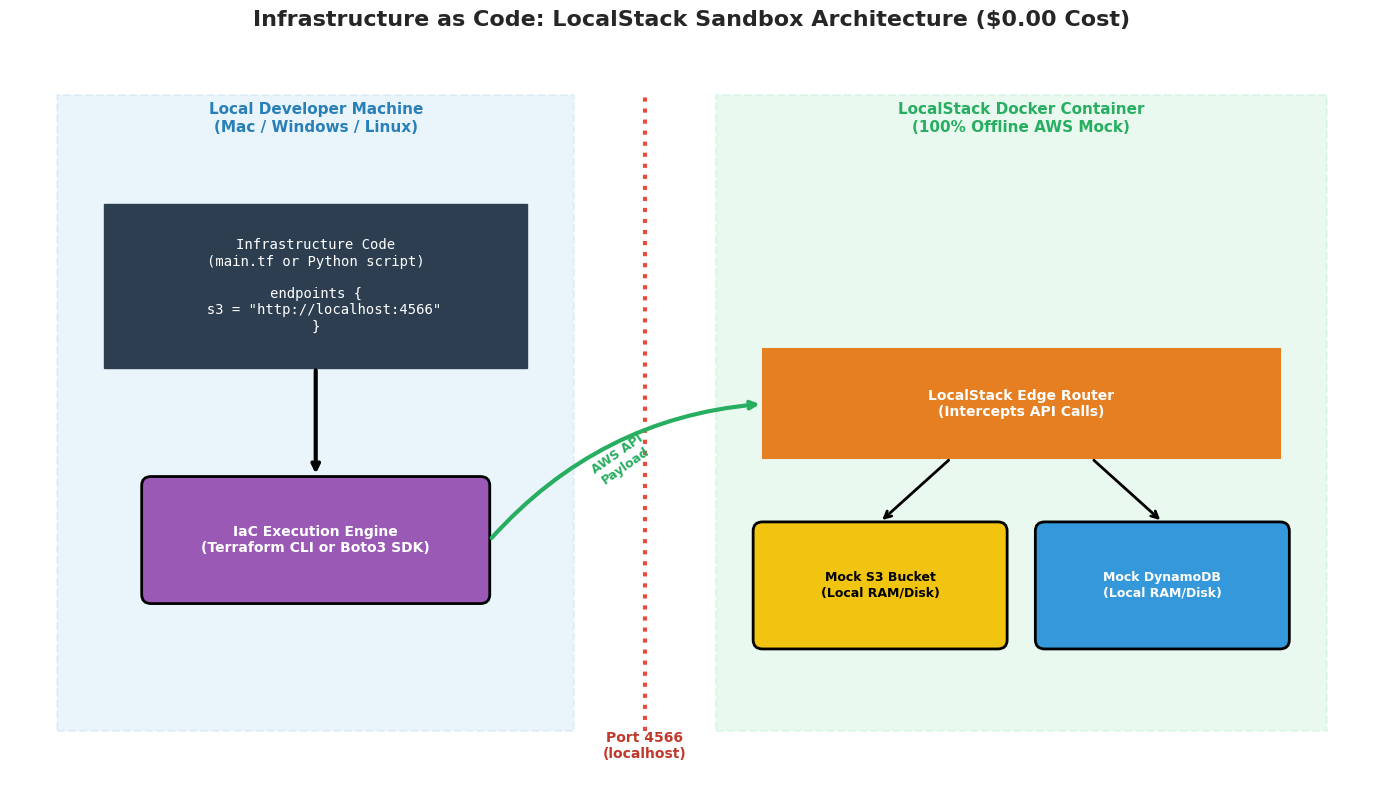

In [7]:
# Visualizing Zero-Cost LocalStack IaC Architecture
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Infrastructure as Code: LocalStack Sandbox Architecture ($0.00 Cost)", fontsize=16, fontweight='bold')

ax.axis('off')

# --- LEFT: THE DEVELOPER WORKSTATION ---
ax.add_patch(patches.Rectangle((0, 0.5), 5.5, 7, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(2.75, 7.1, "Local Developer Machine\n(Mac / Windows / Linux)", ha='center', color='#2980b9', fontweight='bold', fontsize=11)

# Code Block (HCL / Python)
ax.add_patch(patches.Rectangle((0.5, 4.5), 4.5, 1.8, fill=True, color='#2c3e50', edgecolor='black'))
ax.text(2.75, 5.4, "Infrastructure Code\n(main.tf or Python script)\n\nendpoints {\n  s3 = \"http://localhost:4566\"\n}", ha='center', va='center', color='white', fontsize=10, fontfamily='monospace')

# Terraform / Boto3 Engine
engine_box = patches.FancyBboxPatch((1.0, 2.0), 3.5, 1.2, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#9b59b6')
ax.add_patch(engine_box)
ax.text(2.75, 2.6, "IaC Execution Engine\n(Terraform CLI or Boto3 SDK)", ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# Flow from Code to Engine
ax.annotate("", xy=(2.75, 3.3), xytext=(2.75, 4.5), arrowprops=dict(arrowstyle="->", lw=3, color="black"))


# --- MIDDLE: THE NETWORK BARRIER (localhost) ---
ax.plot([6.25, 6.25], [0.5, 7.5], color='#e74c3c', linestyle=':', linewidth=3)
ax.text(6.25, 0.2, "Port 4566\n(localhost)", ha='center', color='#c0392b', fontweight='bold', fontsize=10)


# --- RIGHT: THE LOCALSTACK DOCKER CONTAINER ---
ax.add_patch(patches.Rectangle((7, 0.5), 6.5, 7, fill=True, color='#2ecc71', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(10.25, 7.1, "LocalStack Docker Container\n(100% Offline AWS Mock)", ha='center', color='#27ae60', fontweight='bold', fontsize=11)

# LocalStack Router
ax.add_patch(patches.Rectangle((7.5, 3.5), 5.5, 1.2, fill=True, color='#e67e22', edgecolor='black', linewidth=1.5))
ax.text(10.25, 4.1, "LocalStack Edge Router\n(Intercepts API Calls)", ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# Mocked Resources
ax.add_patch(patches.FancyBboxPatch((7.5, 1.5), 2.5, 1.2, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#f1c40f'))
ax.text(8.75, 2.1, "Mock S3 Bucket\n(Local RAM/Disk)", ha='center', va='center', color='black', fontweight='bold', fontsize=9)

ax.add_patch(patches.FancyBboxPatch((10.5, 1.5), 2.5, 1.2, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#3498db'))
ax.text(11.75, 2.1, "Mock DynamoDB\n(Local RAM/Disk)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)


# --- ROUTING ARROWS ---
# Engine to Router
ax.annotate("", xy=(7.5, 4.1), xytext=(4.6, 2.6), arrowprops=dict(arrowstyle="->", lw=3, color="#27ae60", connectionstyle="arc3,rad=-0.2"))
ax.text(6.0, 3.2, "AWS API\nPayload", ha='center', fontweight='bold', color="#27ae60", fontsize=9, rotation=35)

# Router to Mock Resources
ax.annotate("", xy=(8.75, 2.8), xytext=(9.5, 3.5), arrowprops=dict(arrowstyle="->", lw=2, color="black"))
ax.annotate("", xy=(11.75, 2.8), xytext=(11.0, 3.5), arrowprops=dict(arrowstyle="->", lw=2, color="black"))

plt.xlim(-0.5, 14)
plt.ylim(0, 8)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of LocalStack and Terraform like **A Commercial Flight Simulator vs. Flying a real $100M Boeing 747**:

* **ClickOps in the Real Cloud (Flying Blind)**: You are handed the keys to a real $100M passenger jet (AWS public cloud). You have no training, so you just start pressing buttons on the dashboard. You accidentally turn off the engines (delete the production database) or leave the cargo door open (expose data to the internet). Mistakes here are fatal and cost millions of dollars.
* **Terraform + LocalStack (The Flight Simulator)**: You step into a multi-million dollar hyper-realistic flight simulator (LocalStack). The dashboard, the buttons, and the physics exactly match the real Boeing 747.
* You write a strict pre-flight checklist (Terraform HCL).
* You execute the checklist, taking off and landing the plane inside the simulator.
* If you crash the plane in the simulator, no one gets hurt, and it costs exactly $0.00. You simply press the reset button (`terraform destroy`).
* Once your checklist runs perfectly 100 times in a row inside the simulator, you can confidently walk into the real airplane, load the exact same checklist, and execute it flawlessly in production.



By combining Terraform with LocalStack, you can learn, break, and master enterprise cloud architecture without ever exposing yourself to a single AWS billing surprise.